<a href="https://colab.research.google.com/github/Anukram01/Ecommerce-Sales-Analytics/blob/main/Ecommerce_Sales_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# 1. Generate Realistic E-Commerce / Superstore Dataset
np.random.seed(42)
n_rows = 2000

categories = {
    'Technology': ['Phones', 'Accessories', 'Copiers', 'Machines'],
    'Furniture': ['Chairs', 'Tables', 'Bookcases', 'Furnishings'],
    'Office Supplies': ['Paper', 'Binders', 'Storage', 'Appliances', 'Art']
}

cat_list = np.random.choice(list(categories.keys()), n_rows, p=[0.3, 0.3, 0.4])
subcat_list = [np.random.choice(categories[c]) for c in cat_list]
regions = np.random.choice(['East', 'West', 'Central', 'South'], n_rows)
segments = np.random.choice(['Consumer', 'Corporate', 'Home Office'], n_rows, p=[0.5, 0.3, 0.2])

sales = np.round(np.random.exponential(scale=180, size=n_rows) + 10, 2)
discounts = np.random.choice([0.0, 0.1, 0.2, 0.3, 0.5, 0.7], n_rows, p=[0.3, 0.25, 0.2, 0.1, 0.1, 0.05])

# Real business logic: High discount -> Negative profit margin
margin_rate = np.where(discounts >= 0.3, -0.25 * (discounts / 0.3), np.random.uniform(0.10, 0.35, n_rows))
profits = np.round(sales * margin_rate, 2)

df = pd.DataFrame({
    'Order_ID': [f"CA-2024-{100000 + i}" for i in range(n_rows)],
    'Order_Date': pd.date_range(start='2023-01-01', periods=n_rows, freq='h'),
    'Segment': segments,
    'Region': regions,
    'Category': cat_list,
    'Sub_Category': subcat_list,
    'Sales': sales,
    'Discount': discounts,
    'Profit': profits
})

print("Dataset Created Successfully! Shape:", df.shape)
print("\nPreview of E-Commerce Data:")
df.head(5)

Dataset Created Successfully! Shape: (2000, 9)

Preview of E-Commerce Data:


,Order_ID,Order_Date,Segment,Region,Category,Sub_Category,Sales,Discount,Profit
0,CA-2024-100000,2023-01-01 00:00:00,Consumer,Central,Furniture,Furnishings,264.59,0.1,44.10
1,CA-2024-100001,2023-01-01 01:00:00,Home Office,West,Office Supplies,Storage,177.98,0.2,60.82
2,CA-2024-100002,2023-01-01 02:00:00,Consumer,East,Office Supplies,Appliances,42.84,0.0,6.00
3,CA-2024-100003,2023-01-01 03:00:00,Consumer,East,Furniture,Tables,297.39,0.2,88.27
4,CA-2024-100004,2023-01-01 04:00:00,Corporate,West,Technology,Machines,239.21,0.5,-99.67


Total Sales Revenue: $363,204.39
Total Net Profit:    $33,956.83
Net Profit Margin:   9.35%


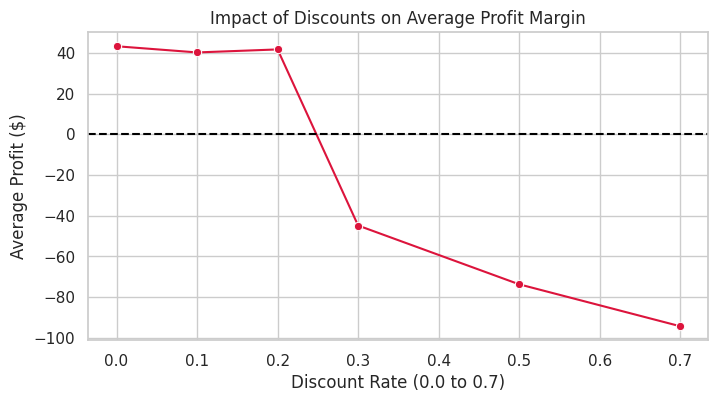

In [9]:
# 1. Connect Python DataFrame to in-memory SQLite database
conn = sqlite3.connect(':memory:')
df.to_sql('ecommerce_sales', conn, index=False, if_exists='replace')

# 2. Key Business Metrics Calculation in Python
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
overall_margin = (total_profit / total_revenue) * 100

print(f"Total Sales Revenue: ${total_revenue:,.2f}")
print(f"Total Net Profit:    ${total_profit:,.2f}")
print(f"Net Profit Margin:   {overall_margin:.2f}%")

# 3. Quick Visual: Profit vs Discount Impact
plt.figure(figsize=(8, 4))
sns.lineplot(data=df, x='Discount', y='Profit', estimator='mean', errorbar=None, marker='o', color='crimson')
plt.title('Impact of Discounts on Average Profit Margin')
plt.xlabel('Discount Rate (0.0 to 0.7)')
plt.ylabel('Average Profit ($)')
plt.axhline(0, color='black', linestyle='--')
plt.show()

In [10]:
# Query 1: Category & Sub-Category Performance with Profit Margin %
query_category = """
SELECT
    Category,
    Sub_Category,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit,
    ROUND((SUM(Profit) * 100.0 / SUM(Sales)), 2) AS profit_margin_pct
FROM ecommerce_sales
GROUP BY Category, Sub_Category
ORDER BY profit_margin_pct ASC;
"""
df_cat_performance = pd.read_sql_query(query_category, conn)

print("--- 1. Bottom 5 Least Profitable / Loss-Making Sub-Categories ---")
print(df_cat_performance.head(5))

# Query 2: Regional Sales & Negative Profit Identification
query_region = """
SELECT
    Region,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit,
    ROUND(AVG(Discount) * 100, 2) AS avg_discount_pct
FROM ecommerce_sales
GROUP BY Region
ORDER BY total_profit DESC;
"""
df_region_performance = pd.read_sql_query(query_region, conn)

print("\n--- 2. Regional Performance & Discount Behavior ---")
print(df_region_performance)

--- 1. Bottom 5 Least Profitable / Loss-Making Sub-Categories ---
          Category Sub_Category  total_sales  total_profit  profit_margin_pct
0  Office Supplies      Binders     26060.60        930.24               3.57
1  Office Supplies   Appliances     28447.80       1063.30               3.74
2       Technology  Accessories     26874.08       1610.76               5.99
3  Office Supplies      Storage     29556.45       2209.29               7.47
4       Technology       Phones     33446.21       2984.60               8.92

--- 2. Regional Performance & Discount Behavior ---
    Region  total_sales  total_profit  avg_discount_pct
0    South    100735.93       9641.66             17.36
1     West     81554.94       8603.73             16.02
2  Central     98494.19       8373.26             18.17
3     East     82419.33       7338.18             17.01


/tmp/ipykernel_1951/2349667426.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_summary, x='Category', y='Profit', ax=axes[0], palette='Blues_d')


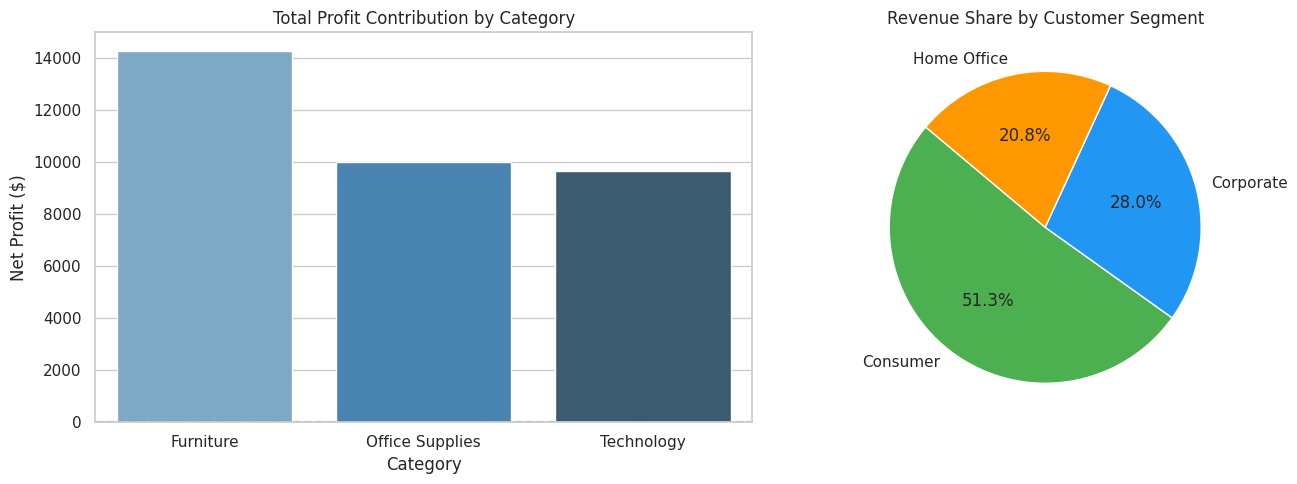

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Total Profit by Product Category
category_summary = df.groupby('Category')['Profit'].sum().reset_index()
sns.barplot(data=category_summary, x='Category', y='Profit', ax=axes[0], palette='Blues_d')
axes[0].set_title('Total Profit Contribution by Category')
axes[0].set_ylabel('Net Profit ($)')
axes[0].axhline(0, color='grey', linestyle='--')

# 2. Revenue Share by Customer Segment
segment_sales = df.groupby('Segment')['Sales'].sum()
axes[1].pie(segment_sales, labels=segment_sales.index, autopct='%1.1f%%',
           startangle=140, colors=['#4CAF50', '#2196F3', '#FF9800'])
axes[1].set_title('Revenue Share by Customer Segment')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1951/2349667426.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_summary, x='Category', y='Profit', ax=axes[0], palette='Blues_d')


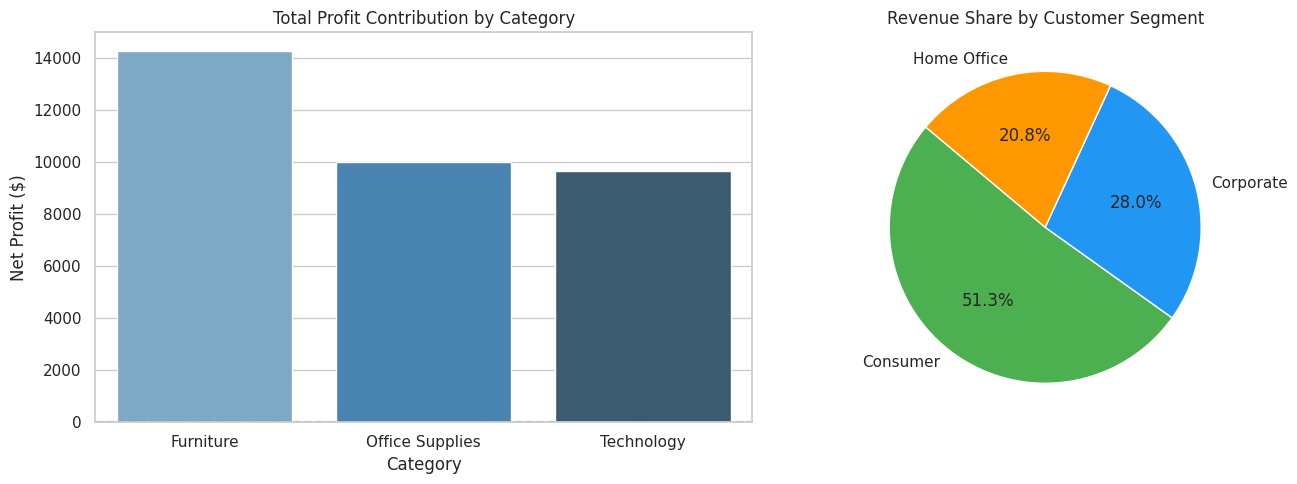

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Total Profit by Product Category
category_summary = df.groupby('Category')['Profit'].sum().reset_index()
sns.barplot(data=category_summary, x='Category', y='Profit', ax=axes[0], palette='Blues_d')
axes[0].set_title('Total Profit Contribution by Category')
axes[0].set_ylabel('Net Profit ($)')
axes[0].axhline(0, color='grey', linestyle='--')

# 2. Revenue Share by Customer Segment
segment_sales = df.groupby('Segment')['Sales'].sum()
axes[1].pie(segment_sales, labels=segment_sales.index, autopct='%1.1f%%',
           startangle=140, colors=['#4CAF50', '#2196F3', '#FF9800'])
axes[1].set_title('Revenue Share by Customer Segment')

plt.tight_layout()
plt.show()